# Lab 07 — Neural network จากศูนย์ (numpy) แล้วเทียบ PyTorch
### An L-layer network: notation, forward with cache, backward, gradient check

**กลุ่ม:** C neural network · **อ่านคู่กับสไลด์หน้า:** 74-80 · **เวลาโดยประมาณ:** 120 นาที · **Dataset:** nnlab.data.load_moons(n=400, noise=0.2)

**ควรทำมาก่อน:** Lab 05-06 (perceptron: forward, BCE cost, backward $dz = a - y$ และ gradient descent)

## จุดประสงค์การเรียนรู้
เมื่อทำ lab นี้จบ นิสิตจะสามารถ
1. อ่านสัญลักษณ์ $L, n^{[l]}, W^{[l]}, b^{[l]}, Z^{[l]}, A^{[l]}$ ของสไลด์ p.76-78 และบอก shape ของทุกตัวได้จาก layer sizes
2. เขียน forward propagation ที่เก็บ cache และ backward propagation ตามสูตร p.80 ด้วย numpy สำหรับ network กี่ชั้นก็ได้
3. อธิบายได้ว่าทำไม `keepdims=True` จำเป็นใน `db` และ bug จะหน้าตาอย่างไรถ้าลืม
4. ตรวจ backward ด้วย gradient checking (central difference) และตีความ relative error
5. เทรน network 2 และ 3 ชั้นบนข้อมูล moons แล้วแสดงว่า decision boundary โค้งได้ (perceptron ทำไม่ได้)
6. แปลง parameter numpy ↔ `torch.nn.Linear` แล้วพิสูจน์ด้วย `np.allclose` ว่าทั้งสอง convention คือการคำนวณเดียวกัน

> **วิธีใช้ notebook นี้:** อ่าน markdown cell ก่อน แล้วรัน code cell ถัดไปด้วย `Shift+Enter` ทีละ cell ตามลำดับ
> ทุก code cell มีคำอธิบายว่าทำอะไรและทำไม ถ้าอยากทดลอง ให้แก้ตัวเลขใน cell แล้วรันซ้ำได้เลย

## เตรียมเครื่องมือ
cell แรกของทุก lab จะ import library ที่ใช้ และตั้ง **seed** ให้ตัวเลขสุ่มเหมือนกันทุกครั้งที่รัน
(ไม่งั้นค่าเริ่มต้นของ weight จะต่างกันทุกรอบ และตัวเลขในหน้าจอจะไม่ตรงกับคำอธิบาย)
lab นี้ใช้ PyTorch ด้วย — `torch.manual_seed` ทำหน้าที่เดียวกับ `set_seed` แต่สำหรับตัวเลขสุ่มฝั่ง torch

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import nnlab                      # package ประกอบ lab (ติดตั้งแล้วด้วย uv sync)
except ImportError:                   # เผื่อเปิดด้วย kernel อื่น: เพิ่ม lab/src เข้า path เอง
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
    import nnlab

from nnlab.utils import set_seed
import torch
from torch import nn
torch.manual_seed(463)
rng = set_seed(463)                   # 463 = เลขวิชา CP463
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline
print("numpy", np.__version__, "| nnlab", nnlab.__version__)

numpy 2.2.6 | nnlab 0.1.0


## สัญลักษณ์ในบทนี้ (สไลด์ p.76)
| สัญลักษณ์ | ความหมาย | shape | ใน notebook |
|---|---|---|---|
| $L$ | จำนวนชั้น **ไม่นับ input layer** | — | `L = len(layer_sizes) - 1` |
| $n^{[l]}$ | จำนวน unit ของชั้น $l$ ($n^{[0]} = n_x$) | — | `layer_sizes[l]` |
| $W^{[l]}$ | weight matrix ของชั้น $l$ (p.77) | $(n^{[l]}, n^{[l-1]})$ | `params["W1"]`, `params["W2"]`, … |
| $b^{[l]}$ | bias vector ของชั้น $l$ (p.78) | $(n^{[l]}, 1)$ | `params["b1"]`, … |
| $Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]}$ | linear combination ของชั้น $l$ | $(n^{[l]}, m)$ | `caches[l-1]["Z"]` |
| $A^{[l]} = g^{[l]}(Z^{[l]})$ | activated values ($A^{[0]} = X$) | $(n^{[l]}, m)$ | `caches[l-1]["A"]` |
| $g^{[l]}$ | activation function ของชั้น $l$ (ReLU / tanh / sigmoid) | — | `acts[l-1]` |
| cache | ค่าที่ forward เก็บไว้ให้ backward ใช้ (p.79) | — | `caches` (list ยาว $L$) |
| $m$ | จำนวน training sample | — | `X.shape[1]` ใน deck convention |

**ระวังเลข index:** สไลด์นับชั้นจาก 1 แต่ Python list นับจาก 0 ดังนั้น `caches[l-1]` และ `acts[l-1]` คือของชั้น $l$
เราตั้งชื่อ key ใน dict เป็น `"W1"`, `"b1"` ตามเลขชั้นของสไลด์ตรงๆ เพื่อลดความสับสน

## ขั้นที่ 1 · ทำไมต้องมีมากกว่าหนึ่ง perceptron (สไลด์ p.74-75)
ใน lab05-06 perceptron ตัวเดียวคือ logistic regression: ลาก **เส้นตรง** เส้นเดียวแบ่งสอง class
ข้อมูล `moons` เป็นพระจันทร์เสี้ยว 2 อันเกี่ยวกัน — ไม่มีเส้นตรงเส้นไหนแบ่งได้หมด
เราจะเทรน `Perceptron` จาก lab05 ดูก่อน คาดว่า accuracy จะติดอยู่ราว 0.85-0.88 และ decision boundary เป็นเส้นตรงที่ตัดพระจันทร์ทั้งสองอัน
สไลด์ p.74 บอกว่า neural network คือ "a collection of perceptrons" — เราจะเอา perceptron หลายตัวมาต่อกันเป็นชั้นเพื่อแก้ปัญหานี้

X (400, 2) | y (400,) | สัดส่วน class 1 = 0.5
accuracy ของ perceptron = 0.875   ← ติดเพดานเพราะ boundary เป็นเส้นตรง


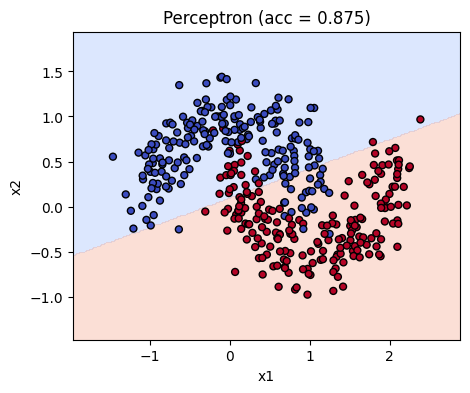

In [2]:
from nnlab.data import load_moons
from nnlab.perceptron import Perceptron
from nnlab.plotting import plot_decision_boundary

X, y = load_moons(n=400, noise=0.2)          # X: (m, 2) sample เป็นแถว (library convention), y: (m,)
m = X.shape[0]
print("X", X.shape, "| y", y.shape, "| สัดส่วน class 1 =", y.mean())

perc = Perceptron(lr=0.5, epochs=1000).fit(X, y)
acc_perc = perc.evaluate(X, y)["accuracy"]
print(f"accuracy ของ perceptron = {acc_perc:.3f}   ← ติดเพดานเพราะ boundary เป็นเส้นตรง")

fig, ax = plt.subplots(figsize=(5, 4))
plot_decision_boundary(perc.predict, X, y, ax=ax, title=f"Perceptron (acc = {acc_perc:.3f})")
plt.show()

## ขั้นที่ 2 · สถาปัตยกรรมและ notation (สไลด์ p.75-78)
สไลด์ p.75 นับชั้นตามจำนวนชั้นที่มี weight: perceptron = 1-layer network, มี hidden layer 1 ชั้น = 2-layer network
เราจะเริ่มจาก network เล็กๆ `layer_sizes = [2, 5, 3, 1]` คือ $n_x = 2$ input, hidden 5 และ 3 unit, output 1 unit → $L = 3$

กติกา shape จากสไลด์ p.77-78 มีแค่ 2 ข้อ แต่ต้องจำให้ได้ขึ้นใจ
- $W^{[l]}$ มี shape $(n^{[l]}, n^{[l-1]})$ — **แถว = unit ของชั้นนี้, คอลัมน์ = unit ของชั้นก่อนหน้า**
- $b^{[l]}$ มี shape $(n^{[l]}, 1)$ — column vector เสมอ (ไม่ใช่ `(n,)`)

cell นี้พิมพ์ตาราง shape ของทุกชั้นจาก `layer_sizes` โดยยังไม่สร้างตัวเลขจริง — เช็คกับ p.77 ว่า $W^{[3]}$ ของ network 4 ชั้นในสไลด์มี shape $(3, 4)$ เพราะ $n^{[3]} = 3, n^{[2]} = 4$

> **Convention ที่ใช้ในส่วนนี้: สไลด์ (deck)** — `X` มี shape `(n_x, m)` sample เป็น**คอลัมน์**, `Y` มี shape `(1, m)`, `w` มี shape `(n_x, 1)` และ `Z = w.T @ X + b`

In [3]:
layer_sizes = [2, 5, 3, 1]                 # n[0]=n_x=2, n[1]=5, n[2]=3, n[3]=1
L = len(layer_sizes) - 1                   # จำนวนชั้นไม่นับ input → 3
print(f"L = {L} ชั้น (hidden 2 ชั้น + output 1 ชั้น)\n")
print(f"{'l':>3} | {'n[l-1]':>6} | {'n[l]':>4} | {'W[l] shape':>12} | {'b[l] shape':>10}")
print("-" * 50)
for l in range(1, L + 1):
    n_prev, n_l = layer_sizes[l - 1], layer_sizes[l]
    print(f"{l:>3} | {n_prev:>6} | {n_l:>4} | {str((n_l, n_prev)):>12} | {str((n_l, 1)):>10}")

L = 3 ชั้น (hidden 2 ชั้น + output 1 ชั้น)

  l | n[l-1] | n[l] |   W[l] shape | b[l] shape
--------------------------------------------------
  1 |      2 |    5 |       (5, 2) |     (5, 1)
  2 |      5 |    3 |       (3, 5) |     (3, 1)
  3 |      3 |    1 |       (1, 3) |     (1, 1)


### สร้าง parameter เริ่มต้น
weight ต้อง **สุ่ม** ไม่ใช่ศูนย์ — ถ้าทุก unit ในชั้นเดียวกันเริ่มเท่ากัน มันจะได้ gradient เท่ากัน อัปเดตเท่ากัน และเป็นตัวเดียวกันตลอดไป (symmetry problem — ลองในแบบฝึกหัด 7.4 ท้าย lab)
เราใช้ **He initialization**: $W^{[l]} \sim \mathcal{N}(0, 2/n^{[l-1]})$ ซึ่งเหมาะกับ ReLU (ทำให้ variance ของ $Z$ ไม่ระเบิดหรือหดเมื่อชั้นลึกขึ้น) ส่วน bias เริ่มที่ศูนย์ได้เพราะ weight สุ่มแล้วทำลาย symmetry ให้แล้ว
สังเกตว่าเราส่ง `rng` เข้าไปเพื่อให้ตัวเลขสุ่มซ้ำได้ และ cell พิมพ์ shape ทุกตัวให้ตรงกับตารางด้านบน

In [4]:
def init_params(layer_sizes, rng):
    """He initialization: W[l] ~ N(0, 2/n[l-1]) shape (n[l], n[l-1]), b[l] = 0 shape (n[l], 1)  (สไลด์ p.77-78)"""
    params = {}
    for l in range(1, len(layer_sizes)):
        n_l, n_prev = layer_sizes[l], layer_sizes[l - 1]
        params[f"W{l}"] = rng.standard_normal((n_l, n_prev)) * np.sqrt(2.0 / n_prev)   # W[l]: (n[l], n[l-1])
        params[f"b{l}"] = np.zeros((n_l, 1))                                           # b[l]: (n[l], 1)
    return params

params = init_params(layer_sizes, rng)
for k, v in params.items():
    print(f"{k}: shape {v.shape}")
print("\nW1 =\n", params["W1"], "\nb1 =\n", params["b1"])
print("\nจำนวน parameter ทั้งหมด:", sum(v.size for v in params.values()),
      "= (2·5 + 5) + (5·3 + 3) + (3·1 + 1)")

W1: shape (5, 2)
b1: shape (5, 1)
W2: shape (3, 5)
b2: shape (3, 1)
W3: shape (1, 3)
b3: shape (1, 1)

W1 =
 [[-0.5015 -0.2821]
 [-0.4781 -1.6603]
 [ 0.6462 -0.1278]
 [-1.2871  0.2021]
 [ 0.5188 -0.2969]] 
b1 =
 [[0.]
 [0.]
 [0.]
 [0.]
 [0.]]

จำนวน parameter ทั้งหมด: 37 = (2·5 + 5) + (5·3 + 3) + (3·1 + 1)


## ขั้นที่ 3 · forward propagation พร้อม cache (สไลด์ p.79-80)
ทุกชั้นทำสองบรรทัดเดียวกัน (p.80):
$$Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]}, \qquad A^{[l]} = g^{[l]}(Z^{[l]})$$
โดย $A^{[0]} = X$ มี shape $(n_x, m)$ — sample เป็นคอลัมน์ตาม deck convention จึงต้อง **transpose** ข้อมูลจาก `load_moons` ก่อน
ตรวจ shape: $(n^{[l]}, n^{[l-1]}) @ (n^{[l-1]}, m) \to (n^{[l]}, m)$ แล้วบวก $b^{[l]}$ shape $(n^{[l]}, 1)$ ซึ่ง broadcasting ยืดไปทุกคอลัมน์ (ทุก sample) ให้เอง — นี่คือเหตุผลที่ $b$ ต้องเป็น $(n, 1)$

**cache** (p.79): backward ต้องใช้ $A^{[l-1]}$ (คูณหา $dW$) และ $Z^{[l]}$ (หา $g'$) ของทุกชั้น เราจึงเก็บไว้ใน list ตอน forward แทนที่จะคำนวณใหม่
activation function ใช้ตัวที่เขียนไว้แล้วใน `nnlab.activations` (lab03) — ReLU สำหรับ hidden, sigmoid สำหรับ output เพราะเป็น binary classification

In [5]:
from nnlab.activations import relu, d_relu, tanh, d_tanh, sigmoid, d_sigmoid
ACT = {"relu": (relu, d_relu), "tanh": (tanh, d_tanh), "sigmoid": (sigmoid, d_sigmoid)}   # ชื่อ → (g, g')

def forward(X, params, acts):
    """forward ทุกชั้น คืน (A[L], caches) — caches[l-1] = {A_prev, Z, A} ของชั้น l  (สไลด์ p.79-80)"""
    L = len(acts)
    A = X                                                   # A[0] = X: (n_x, m)
    caches = []
    for l in range(1, L + 1):
        g, _ = ACT[acts[l - 1]]
        A_prev = A
        Z = params[f"W{l}"] @ A_prev + params[f"b{l}"]       # (n[l], n[l-1]) @ (n[l-1], m) + (n[l], 1) → (n[l], m)
        A = g(Z)                                            # A[l]: (n[l], m)
        caches.append({"A_prev": A_prev, "Z": Z, "A": A})
    return A, caches

X_deck = X.T                                                # (2, 400)  sample เป็นคอลัมน์
Y = y.reshape(1, -1).astype(float)                          # (1, 400)
print("X_deck", X_deck.shape, "| Y", Y.shape)

acts = ["relu", "relu", "sigmoid"]                          # g[1], g[2], g[3]
A_L, caches = forward(X_deck, params, acts)
for l, c in enumerate(caches, start=1):
    print(f"ชั้น {l}: A[{l-1}] {str(c['A_prev'].shape):>9} → Z[{l}] {str(c['Z'].shape):>9} → A[{l}] {str(c['A'].shape):>9}   g = {acts[l-1]}")
print("\nA[L] 5 sample แรก:", A_L[0, :5], " ← ความน่าจะเป็นก่อนเทรน (ยังมั่ว)")

X_deck (2, 400) | Y (1, 400)
ชั้น 1: A[0]  (2, 400) → Z[1]  (5, 400) → A[1]  (5, 400)   g = relu
ชั้น 2: A[1]  (5, 400) → Z[2]  (3, 400) → A[2]  (3, 400)   g = relu
ชั้น 3: A[2]  (3, 400) → Z[3]  (1, 400) → A[3]  (1, 400)   g = sigmoid

A[L] 5 sample แรก: [0.2608 0.4895 0.4749 0.225  0.3292]  ← ความน่าจะเป็นก่อนเทรน (ยังมั่ว)


### cost function
output layer เป็น sigmoid + binary cross-entropy เหมือน perceptron (สไลด์ p.17-18): $\mathcal{J} = \frac{1}{m}\sum_i \mathcal{L}(a^{[L](i)}, y^{(i)})$
ค่าก่อนเทรนควรอยู่ใกล้ $-\log 0.5 \approx 0.693$ (ทายมั่ว) — ถ้าสูงกว่ามากแปลว่า weight เริ่มต้นใหญ่เกินจนทายมั่นใจผิดๆ

In [6]:
from nnlab.losses import binary_cross_entropy

def compute_cost(A_L, Y):
    return binary_cross_entropy(A_L, Y)       # (1/m) Σ -(y log a + (1-y) log(1-a))

J0 = compute_cost(A_L, Y)
print(f"cost ก่อนเทรน J = {J0:.4f}   (เทียบ -log(0.5) = {-np.log(0.5):.4f})")

cost ก่อนเทรน J = 0.6507   (เทียบ -log(0.5) = 0.6931)


## ขั้นที่ 4 · backward propagation (สไลด์ p.80)
เริ่มจากชั้น output: sigmoid + BCE ให้ $dZ^{[L]} = A^{[L]} - Y$ (พิสูจน์ไว้ใน lab06 — สูตรเดียวกับ perceptron)
จากนั้นไล่ย้อนจากชั้น $L$ ลงมาถึงชั้น 1 ด้วย 4 สูตรของ p.80

| สูตร (p.80) | numpy | shape |
|---|---|---|
| $dW^{[l]} = \frac{1}{m}\, dZ^{[l]} A^{[l-1]T}$ | `dZ @ A_prev.T / m` | $(n^{[l]}, m)(m, n^{[l-1]}) \to (n^{[l]}, n^{[l-1]})$ = shape ของ $W^{[l]}$ ✓ |
| $db^{[l]} = \frac{1}{m}\sum_{i} dZ^{[l](i)}$ | `np.sum(dZ, axis=1, keepdims=True) / m` | $(n^{[l]}, 1)$ = shape ของ $b^{[l]}$ ✓ |
| $dA^{[l-1]} = W^{[l]T} dZ^{[l]}$ | `W.T @ dZ` | $(n^{[l-1]}, n^{[l]})(n^{[l]}, m) \to (n^{[l-1]}, m)$ |
| $dZ^{[l-1]} = dA^{[l-1]} * g'^{[l-1]}(Z^{[l-1]})$ | `dA_prev * dg(Z_prev)` | elementwise `*` ไม่ใช่ `@` |

หลักการตรวจง่ายๆ: **gradient ของอะไร ต้องมี shape เท่ากับสิ่งนั้น** (`dW1.shape == W1.shape`) — cell ท้ายๆ จะ assert ข้อนี้ทุกตัว
สังเกตว่า `A_prev` และ `Z` ที่ใช้ ดึงจาก `caches` ทั้งหมด ไม่ต้องคำนวณ forward ซ้ำ

In [7]:
def backward(Y, caches, params, acts):
    """backward ทุกชั้นตามสูตร p.80 คืน grads = {"dW1", "db1", "dW2", ...}"""
    L = len(caches)
    m = Y.shape[1]
    grads = {}
    dZ = caches[-1]["A"] - Y                                        # dZ[L]: (n[L], m) = (1, m)  sigmoid + BCE
    for l in range(L, 0, -1):
        c = caches[l - 1]
        grads[f"dW{l}"] = (dZ @ c["A_prev"].T) / m                  # (n[l], m) @ (m, n[l-1]) → (n[l], n[l-1])
        grads[f"db{l}"] = np.sum(dZ, axis=1, keepdims=True) / m     # (n[l], 1)  ← keepdims สำคัญ!
        if l > 1:                                                   # ชั้น 1 ไม่ต้องส่ง gradient ต่อไปที่ X
            dA_prev = params[f"W{l}"].T @ dZ                        # (n[l-1], n[l]) @ (n[l], m) → (n[l-1], m)
            _, dg = ACT[acts[l - 2]]                                # g' ของชั้น l-1
            dZ = dA_prev * dg(caches[l - 2]["Z"])                   # dZ[l-1]: (n[l-1], m)  elementwise
    return grads

grads = backward(Y, caches, params, acts)
for k in params:
    print(f"{k} {str(params[k].shape):>7}  ↔  d{k} {str(grads['d' + k].shape):>7}")
    assert grads["d" + k].shape == params[k].shape, f"shape ของ d{k} ไม่ตรงกับ {k}"
print("\nshape ของทุก gradient ตรงกับ parameter ✓")
print("dW3 =", grads["dW3"], " db3 =", grads["db3"])

W1  (5, 2)  ↔  dW1  (5, 2)
b1  (5, 1)  ↔  db1  (5, 1)
W2  (3, 5)  ↔  dW2  (3, 5)
b2  (3, 1)  ↔  db2  (3, 1)
W3  (1, 3)  ↔  dW3  (1, 3)
b3  (1, 1)  ↔  db3  (1, 1)

shape ของทุก gradient ตรงกับ parameter ✓
dW3 = [[ 0.0462 -0.027  -0.0019]]  db3 = [[-0.0684]]


### ถ้าลืม `keepdims=True` จะเกิดอะไร
`np.sum(dZ, axis=1)` ยุบมิติ 1 ทิ้ง ได้ shape `(n,)` แทน `(n, 1)` โปรแกรม **ไม่ error** ทันที — ตอนอัปเดต `b - lr * db`
numpy จะ broadcast `(n, 1) - (n,)` เป็น `(n, n)` อย่างเงียบๆ (กติกา lab01: เทียบจากขวา 1 กับ n ยืดได้) ทำให้ $b^{[2]}$ กลายเป็น matrix 3×3
แล้วไปพังตอน forward รอบถัดไปที่ `W2 @ A1 + b2` เพราะ `(3, 400) + (3, 3)` broadcast ไม่ได้ — error โผล่ **คนละที่** กับต้นเหตุ
cell นี้ทำให้ bug เกิดจริงในชั้น 2 ($n^{[2]} = 3$) แล้วดัก error ไว้ให้ดู

In [8]:
dZ3 = caches[2]["A"] - Y                                  # (1, 400)
dA2 = params["W3"].T @ dZ3                                # (3, 1) @ (1, 400) → (3, 400)
dZ2 = dA2 * d_relu(caches[1]["Z"])                        # (3, 400)

db2_good = np.sum(dZ2, axis=1, keepdims=True) / m         # (3, 1)
db2_bad = np.sum(dZ2, axis=1) / m                         # (3,)   ← ลืม keepdims
print("keepdims=True :", db2_good.shape, "| ลืม keepdims:", db2_bad.shape)

b2_good = params["b2"] - 0.1 * db2_good                   # (3, 1) - (3, 1) → (3, 1) ✓
b2_bad = params["b2"] - 0.1 * db2_bad                     # (3, 1) - (3,)   → (3, 3) ✗ เงียบๆ ไม่ error
print("b2 หลังอัปเดต (ถูก):", b2_good.shape, "| (ผิด):", b2_bad.shape, " ← กลายเป็น matrix โดยไม่รู้ตัว")

try:
    Z2_bad = params["W2"] @ caches[0]["A"] + b2_bad       # (3, 400) + (3, 3) → broadcast ไม่ได้
except ValueError as e:
    print("forward รอบถัดไปพัง → ValueError:", e)

keepdims=True : (3, 1) | ลืม keepdims: (3,)
b2 หลังอัปเดต (ถูก): (3, 1) | (ผิด): (3, 3)  ← กลายเป็น matrix โดยไม่รู้ตัว
forward รอบถัดไปพัง → ValueError: operands could not be broadcast together with shapes (3,400) (3,3) 


## ขั้นที่ 5 · gradient checking — backward ถูกจริงไหม
สูตร backward ผิดได้ง่าย (ลืม transpose, ใช้ `@` แทน `*`, index ชั้นเพี้ยน) และมักผิดแบบ **รันผ่านแต่เรียนไม่รู้เรื่อง**
วิธีตรวจแบบไม่ต้องเชื่อสูตร: ใช้อนุพันธ์เชิงตัวเลขจาก lab03 (p.9) แต่แบบ **central difference** ที่แม่นกว่า
$$\frac{\partial \mathcal{J}}{\partial \theta} \approx \frac{\mathcal{J}(\theta + \varepsilon) - \mathcal{J}(\theta - \varepsilon)}{2\varepsilon}, \quad \varepsilon = 10^{-7}$$
ขยับ parameter ทีละตัว คำนวณ cost ใหม่สองครั้ง แล้วเทียบกับค่าใน `grads` ด้วย **relative error** $\frac{|a - n|}{|a| + |n|}$ (ค่าที่ดีควร $< 10^{-6}$)

**ข้อควรระวังเรื่อง ReLU:** ReLU ไม่มีอนุพันธ์ที่ $z = 0$ พอดี ตอนนี้ $b = 0$ ทุกตัว ถ้ามี sample ที่ hidden unit ชั้นก่อนหน้าดับหมด (A = 0 ทั้งคอลัมน์) จะได้ $Z = b = 0$ **พอดีเป๊ะ**
การขยับ $\pm\varepsilon$ จะข้ามจุดหักมุม ทำให้ numeric ≠ analytic แม้ backward จะถูก — เราจึงสุ่ม $b$ เล็กน้อยก่อนตรวจ (cell ถัดไปจะโชว์ทั้งสองกรณี)

In [9]:
def numeric_grad(params, key, i, j, X, Y, acts, eps=1e-7):
    """อนุพันธ์เชิงตัวเลขของ cost ต่อ params[key][i, j] ด้วย central difference"""
    old = params[key][i, j]
    params[key][i, j] = old + eps
    J_plus = compute_cost(forward(X, params, acts)[0], Y)
    params[key][i, j] = old - eps
    J_minus = compute_cost(forward(X, params, acts)[0], Y)
    params[key][i, j] = old                                  # คืนค่าเดิมเสมอ
    return (J_plus - J_minus) / (2 * eps)

params_chk = init_params(layer_sizes, rng)
for k in params_chk:
    if k.startswith("b"):
        params_chk[k] = 0.1 * rng.standard_normal(params_chk[k].shape)    # b ไม่เป็นศูนย์ → ไม่มี Z = 0 พอดี

A_chk, caches_chk = forward(X_deck, params_chk, acts)
grads_chk = backward(Y, caches_chk, params_chk, acts)

print(f"{'parameter':>10} | {'analytic':>12} | {'numeric':>12} | {'rel. error':>10}")
for key, i, j in [("W1", 0, 0), ("W1", 4, 1), ("b1", 2, 0), ("W2", 1, 3), ("b2", 0, 0), ("W3", 0, 2), ("b3", 0, 0)]:
    a = grads_chk["d" + key][i, j]
    n = numeric_grad(params_chk, key, i, j, X_deck, Y, acts)
    rel = abs(a - n) / (abs(a) + abs(n) + 1e-12)
    print(f"{key + f'[{i},{j}]':>10} | {a:>12.8f} | {n:>12.8f} | {rel:>10.2e}")
    assert rel < 1e-6, f"gradient ของ {key}[{i},{j}] ไม่ตรง"
print("\nทุกตัวที่สุ่มตรวจ relative error < 1e-6 ✓")

 parameter |     analytic |      numeric | rel. error
   W1[0,0] |   0.03109225 |   0.03109225 |   1.68e-08
   W1[4,1] |  -0.02486527 |  -0.02486527 |   1.90e-08
   b1[2,0] |   0.04867546 |   0.04867546 |   6.41e-09
   W2[1,3] |  -0.00613298 |  -0.00613298 |   3.35e-08
   b2[0,0] |  -0.25092725 |  -0.25092725 |   7.96e-10
   W3[0,2] |  -0.81876743 |  -0.81876743 |   5.46e-11
   b3[0,0] |  -0.13526345 |  -0.13526345 |   2.98e-09

ทุกตัวที่สุ่มตรวจ relative error < 1e-6 ✓


### ตรวจทุก parameter ด้วย `nnlab.nn.gradient_check`
เวอร์ชันใน package วนทุกตัว (37 ตัว × forward 2 ครั้ง) แล้วรวมเป็นตัวเลขเดียว $\frac{\|a - n\|}{\|a\| + \|n\|}$
cell นี้แสดง 3 กรณีเพื่อให้เห็นข้อควรระวังเรื่อง ReLU ข้างบนจริงๆ
1. ReLU กับ $b = 0$ จาก `nnlab.nn.init_params(seed=463)` — จะได้ค่าใหญ่ระดับ $10^{-3}$ **ทั้งที่ backward ถูก** เพราะมี $Z^{[2]}, Z^{[3]}$ บางตัวเป็น 0 พอดี (cell นับให้ดู)
2. parameter เดิมแต่สุ่ม $b$ เล็กน้อย → กลับมา $< 10^{-6}$
3. เปลี่ยน hidden เป็น tanh (เรียบทุกจุด) กับ $b = 0$ → $< 10^{-6}$ เช่นกัน

บทเรียน: gradient check ที่ fail ให้สงสัยสูตรก่อน แต่ถ้าใช้ ReLU ให้เช็คด้วยว่ามี $Z = 0$ พอดีหรือไม่

In [10]:
from nnlab.nn import gradient_check, init_params as nnlab_init_params

params_zero_b = nnlab_init_params(layer_sizes, seed=463)                 # b = 0 ทุกชั้น (deterministic)
_, caches_zb = forward(X_deck, params_zero_b, acts)
n_exact_zero = sum(int((c["Z"] == 0).sum()) for c in caches_zb)
err_relu_zero_b = gradient_check(X_deck, Y, params_zero_b, acts)
print(f"1) ReLU, b = 0        : rel. error = {err_relu_zero_b:.2e}   (มี Z = 0 พอดี {n_exact_zero} ตัว → จุดหักมุมของ ReLU)")

params_rand_b = {k: (v.copy() if k.startswith("W") else 0.1 * rng.standard_normal(v.shape)) for k, v in params_zero_b.items()}
err_relu_rand_b = gradient_check(X_deck, Y, params_rand_b, acts)
print(f"2) ReLU, b สุ่มเล็กน้อย : rel. error = {err_relu_rand_b:.2e}")
assert err_relu_rand_b < 1e-6

err_tanh = gradient_check(X_deck, Y, params_zero_b, ["tanh", "tanh", "sigmoid"])
print(f"3) tanh, b = 0        : rel. error = {err_tanh:.2e}")
assert err_tanh < 1e-6
print("\nbackward ของเราถูกต้อง ✓ (กรณี 2 และ 3 < 1e-6)")

1) ReLU, b = 0        : rel. error = 2.07e-03   (มี Z = 0 พอดี 71 ตัว → จุดหักมุมของ ReLU)
2) ReLU, b สุ่มเล็กน้อย : rel. error = 2.53e-09
3) tanh, b = 0        : rel. error = 2.33e-09

backward ของเราถูกต้อง ✓ (กรณี 2 และ 3 < 1e-6)


## ขั้นที่ 6 · training loop: 2 ชั้น vs 3 ชั้น
มีครบแล้ว: `init_params` → วน epoch { `forward` → `compute_cost` → `backward` → อัปเดต $\theta := \theta - \alpha\, d\theta$ ทุกตัว }
เป็น **batch gradient descent** (ใช้ทั้ง 400 sample ทุก epoch) เหมือน perceptron ใน lab05 — mini-batch จะเรียนใน lab09
ฟังก์ชัน `train` รับ `params` เริ่มต้นได้ด้วย (จะใช้เทียบกับ `nnlab` ตอนท้าย) และ `predict` แปลงความน่าจะเป็นเป็น label ด้วย threshold 0.5

เราจะเทรน 2 แบบด้วย learning rate 0.3 และ 1500 epoch เท่ากัน
- `[2, 8, 1]` — 2-layer network (hidden 1 ชั้น 8 unit) ตามสไลด์ p.75 กลาง
- `[2, 16, 8, 1]` — 3-layer network (hidden 2 ชั้น) ตามสไลด์ p.75 ขวา

คาดว่า cost จะลงต่ำกว่า perceptron มาก และ accuracy ขึ้นไปราว 0.96-0.98

In [11]:
def train(X, Y, layer_sizes, acts, lr, epochs, params=None):
    """batch gradient descent: คืน (params ที่เทรนแล้ว, list ของ cost ต่อ epoch)"""
    params = init_params(layer_sizes, rng) if params is None else {k: v.copy() for k, v in params.items()}
    costs = []
    for epoch in range(epochs):
        A_L, caches = forward(X, params, acts)               # A_L: (1, m)
        costs.append(compute_cost(A_L, Y))
        grads = backward(Y, caches, params, acts)
        for k in params:
            params[k] -= lr * grads["d" + k]                 # θ := θ − α dθ  (shape เท่ากันทุกคู่)
    return params, costs

def predict(params, acts, X_rows):
    """รับ X แบบ (m, n_x) → label (m,) เพื่อใช้กับ plot_decision_boundary"""
    A_L, _ = forward(X_rows.T, params, acts)                 # transpose เข้า deck convention ก่อน
    return (A_L.reshape(-1) >= 0.5).astype(int)

acts2, acts3 = ["relu", "sigmoid"], ["relu", "relu", "sigmoid"]
params2, costs2 = train(X_deck, Y, [2, 8, 1], acts2, lr=0.3, epochs=1500)
params3, costs3 = train(X_deck, Y, [2, 16, 8, 1], acts3, lr=0.3, epochs=1500)

acc2 = np.mean(predict(params2, acts2, X) == y)
acc3 = np.mean(predict(params3, acts3, X) == y)
print(f"perceptron      : accuracy {acc_perc:.4f}")
print(f"2-layer [2,8,1] : cost {costs2[0]:.4f} → {costs2[-1]:.4f}   accuracy {acc2:.4f}")
print(f"3-layer [2,16,8,1]: cost {costs3[0]:.4f} → {costs3[-1]:.4f}   accuracy {acc3:.4f}")

perceptron      : accuracy 0.8750
2-layer [2,8,1] : cost 0.7556 → 0.0883   accuracy 0.9600
3-layer [2,16,8,1]: cost 1.0850 → 0.0678   accuracy 0.9750


กราฟซ้าย: cost ต่อ epoch ของทั้งสอง network (เทียบกับ perceptron ที่ค้างอยู่สูง) · สามกราฟขวา: decision boundary
สังเกตว่า boundary ของ network **โค้งตามพระจันทร์** ได้ — hidden unit แต่ละตัวคือ perceptron ที่ลากเส้นตรงหนึ่งเส้น ชั้น output เอาเส้นเหล่านั้นมาประกอบกัน
network 3 ชั้นได้ boundary ที่ซับซ้อนกว่าเล็กน้อย (แต่ก็เสี่ยง overfitting มากกว่า — เรื่องของ lab08)

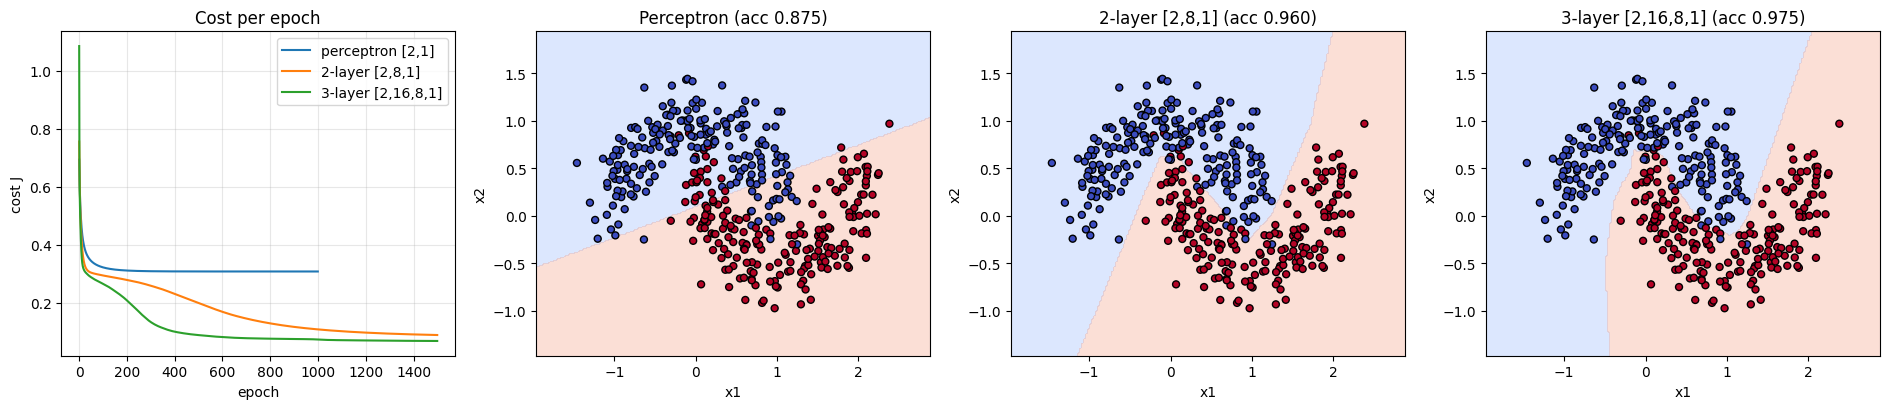

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
axes[0].plot(perc.history_["cost"], label="perceptron [2,1]")
axes[0].plot(costs2, label="2-layer [2,8,1]")
axes[0].plot(costs3, label="3-layer [2,16,8,1]")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cost J"); axes[0].set_title("Cost per epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
plot_decision_boundary(perc.predict, X, y, ax=axes[1], title=f"Perceptron (acc {acc_perc:.3f})")
plot_decision_boundary(lambda G: predict(params2, acts2, G), X, y, ax=axes[2], title=f"2-layer [2,8,1] (acc {acc2:.3f})")
plot_decision_boundary(lambda G: predict(params3, acts3, G), X, y, ax=axes[3], title=f"3-layer [2,16,8,1] (acc {acc3:.3f})")
plt.tight_layout(); plt.show()

## ขั้นที่ 7 · numpy | torch เทียบบรรทัดต่อบรรทัด
PyTorch วาง sample เป็น **แถว** (`X` shape `(m, n_x)`) — ตรงข้ามกับสไลด์ แต่ `nn.Linear(n_in, n_out)` เก็บ `weight` shape `(n_out, n_in)` ซึ่ง**เท่ากับ** $W^{[l]}$ $(n^{[l]}, n^{[l-1]})$ ของสไลด์พอดี
ต่างกันแค่วิธีคูณ: torch คำนวณ `x @ W.T + b` (แถว) ส่วนสไลด์คำนวณ `W @ X + b` (คอลัมน์) — สองนิพจน์นี้เป็น transpose ของกันและกัน

| สไลด์ / numpy (deck) | PyTorch `nn.Linear` (lib) |
|---|---|
| `X` `(n_x, m)` | `x` `(m, n_x)` |
| `W[l]` `(n[l], n[l-1])` | `linear.weight` `(n_out, n_in)` — **shape เดียวกัน** |
| `b[l]` `(n[l], 1)` | `linear.bias` `(n_out,)` — 1 มิติ |
| `Z = W @ A_prev + b` `(n[l], m)` | `z = a_prev @ weight.T + bias` `(m, n_out)` |
| `A[L]` = sigmoid แล้ว | model คืน **logits** (ยังไม่ sigmoid) → ใช้ `BCEWithLogitsLoss` |

เราจะสร้าง `nn.Sequential` โครงเดียวกับ `[2, 16, 8, 1]` แล้ว **copy weight จาก numpy ที่เทรนแล้วเข้า torch** จากนั้น forward ข้อมูลเดียวกันและ assert ว่า logits ของ torch เท่ากับ $Z^{[L]}$ ของ numpy ทุกตัว
(ใช้ `.double()` ให้ torch คำนวณ float64 เหมือน numpy จะได้เทียบกันได้ระดับ 1e-10 — โมเดลจริงใช้ float32)

> **Convention ที่ใช้ในส่วนนี้: library (pandas / scikit-learn / PyTorch)** — `X` มี shape `(m, n_x)` sample เป็น**แถว**, `y` มี shape `(m,)` และ `Z = X @ W.T + b`

In [13]:
model = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 8), nn.ReLU(), nn.Linear(8, 1)).double()
linears = [layer for layer in model if isinstance(layer, nn.Linear)]        # 3 ชั้นที่มี parameter

with torch.no_grad():                                        # copy ค่าโดยไม่บันทึกลง computation graph
    for l, lin in enumerate(linears, start=1):
        lin.weight.copy_(torch.tensor(params3[f"W{l}"]))      # weight (n_out, n_in) = W[l] (n[l], n[l-1]) copy ตรงๆ
        lin.bias.copy_(torch.tensor(params3[f"b{l}"].ravel()))   # bias (n_out,) = b[l] (n[l], 1) บีบเป็น 1 มิติ
        print(f"ชั้น {l}: numpy W{l} {str(params3[f'W{l}'].shape):>8} b{l} {str(params3[f'b{l}'].shape):>7}  |  torch weight {str(tuple(lin.weight.shape)):>8} bias {tuple(lin.bias.shape)}")

X_t = torch.tensor(X)                                        # (m, 2) float64 sample เป็นแถว
logits = model(X_t)                                          # (m, 1)
A_L3, caches3 = forward(X_deck, params3, acts3)              # numpy ฝั่งสไลด์
Z_L = caches3[-1]["Z"]                                       # (1, m) ค่าก่อน sigmoid

print("\ntorch logits", tuple(logits.shape), "| numpy Z[L]", Z_L.shape, "→ transpose แล้วเทียบ")
assert np.allclose(logits.detach().numpy().T, Z_L, atol=1e-5)
print("torch logits == numpy Z[L] ✓  ผลต่างสูงสุด =", np.abs(logits.detach().numpy().T - Z_L).max())

# ชั้นแรกทีละบรรทัด: x @ W.T + b (แถว)  กับ  W @ X + b (คอลัมน์)
z1_torch = X_t @ linears[0].weight.T + linears[0].bias      # (m, 2) @ (2, 16) + (16,) → (m, 16)
Z1_numpy = params3["W1"] @ X_deck + params3["b1"]            # (16, 2) @ (2, m) + (16, 1) → (16, m)
assert np.allclose(z1_torch.detach().numpy(), Z1_numpy.T)
print("z1 (m, 16) ของ torch == Z1.T ของ numpy ✓  — สองนิพจน์คือ transpose ของกัน")

ชั้น 1: numpy W1  (16, 2) b1 (16, 1)  |  torch weight  (16, 2) bias (16,)
ชั้น 2: numpy W2  (8, 16) b2  (8, 1)  |  torch weight  (8, 16) bias (8,)
ชั้น 3: numpy W3   (1, 8) b3  (1, 1)  |  torch weight   (1, 8) bias (1,)

torch logits (400, 1) | numpy Z[L] (1, 400) → transpose แล้วเทียบ
torch logits == numpy Z[L] ✓  ผลต่างสูงสุด = 7.105427357601002e-15
z1 (m, 16) ของ torch == Z1.T ของ numpy ✓  — สองนิพจน์คือ transpose ของกัน


### backward: autograd ของ torch vs สูตร p.80 ของเรา
torch ไม่ต้องเขียน backward — เรียก `loss.backward()` แล้ว gradient ไปอยู่ใน `.grad` ของทุก parameter
`nn.BCEWithLogitsLoss` = sigmoid + BCE เฉลี่ยทั้ง m sample = `compute_cost` ของเราพอดี (รับ logits จึงต้อง `squeeze` ให้เป็น `(m,)` เท่า `y`)
ถ้าสูตรของเราถูก `linears[0].weight.grad` ต้องเท่ากับ `grads["dW1"]` ทุกตัว — นี่คือ gradient check อีกแบบที่ใช้ autograd เป็นกรรมการ

In [14]:
y_t = torch.tensor(y, dtype=torch.float64)                   # (m,)
loss = nn.BCEWithLogitsLoss()(logits.squeeze(1), y_t)        # logits (m, 1) → (m,)
loss.backward()                                              # autograd คำนวณ .grad ให้ทุก parameter

grads3 = backward(Y, caches3, params3, acts3)                # สูตร p.80 ของเรา
print(f"torch loss = {loss.item():.6f} | numpy cost = {compute_cost(A_L3, Y):.6f}")
assert np.isclose(loss.item(), compute_cost(A_L3, Y))

for l, lin in enumerate(linears, start=1):
    dW_ok = np.allclose(lin.weight.grad.numpy(), grads3[f"dW{l}"], atol=1e-8)
    db_ok = np.allclose(lin.bias.grad.numpy(), grads3[f"db{l}"].ravel(), atol=1e-8)
    print(f"ชั้น {l}: dW{l} ตรงกัน {dW_ok} | db{l} ตรงกัน {db_ok}   (torch weight.grad {tuple(lin.weight.grad.shape)} vs numpy dW{l} {grads3[f'dW{l}'].shape})")
    assert dW_ok and db_ok
print("\nautograd ของ torch ให้ gradient เท่ากับ backward ที่เราเขียนเองทุกชั้น ✓")

torch loss = 0.067735 | numpy cost = 0.067735
ชั้น 1: dW1 ตรงกัน True | db1 ตรงกัน True   (torch weight.grad (16, 2) vs numpy dW1 (16, 2))
ชั้น 2: dW2 ตรงกัน True | db2 ตรงกัน True   (torch weight.grad (8, 16) vs numpy dW2 (8, 16))
ชั้น 3: dW3 ตรงกัน True | db3 ตรงกัน True   (torch weight.grad (1, 8) vs numpy dW3 (1, 8))

autograd ของ torch ให้ gradient เท่ากับ backward ที่เราเขียนเองทุกชั้น ✓


## ขั้นที่ 8 · เทรนด้วย PyTorch และ scikit-learn แล้วเทียบ
ในงานจริงเราไม่เขียน loop เอง: `nnlab.torch_models.TorchTrainer` ห่อ loop มาตรฐานของ torch (`zero_grad → forward → loss → backward → step`)
และ `sklearn.neural_network.MLPClassifier` คือ network แบบเดียวกันที่ scikit-learn เทรนให้ (default ใช้ adam)
เราตั้ง `batch_size=None` (batch GD), `optimizer="sgd"`, `lr=0.3`, 1500 epoch ให้ใกล้ numpy ที่สุด และใช้ `device="cpu"` เพราะโมเดลเล็กมาก (GPU/MPS ไม่ช่วยและทำให้ผลต่างกันเล็กน้อย)
accuracy ทั้งสามควรอยู่ระดับเดียวกัน (~0.96-0.98) — ต่างกันเพราะค่าเริ่มต้นและ optimizer ต่างกัน ไม่ใช่เพราะสูตรต่างกัน

In [15]:
import pandas as pd
from nnlab.torch_models import TorchMLP, TorchTrainer
from sklearn.neural_network import MLPClassifier
from nnlab.utils import Timer

with Timer() as t_torch:
    trainer = TorchTrainer(TorchMLP([2, 16, 8, 1]), loss="bce", optimizer="sgd", lr=0.3, epochs=1500,
                           batch_size=None, device="cpu").fit(X, y)
with Timer() as t_sk:
    sk_mlp = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=463).fit(X, y)

results = pd.DataFrame([
    {"model": "numpy inline [2,16,8,1] sgd lr=0.3", "accuracy": acc3, "final cost": costs3[-1]},
    {"model": "TorchTrainer TorchMLP sgd lr=0.3", "accuracy": trainer.evaluate(X, y)["accuracy"], "final cost": trainer.history_["cost"][-1]},
    {"model": "sklearn MLPClassifier (16,8) adam", "accuracy": sk_mlp.score(X, y), "final cost": sk_mlp.loss_},
    {"model": "Perceptron [2,1]", "accuracy": acc_perc, "final cost": perc.history_["cost"][-1]},
]).round(4)
print(f"เวลาเทรน torch {t_torch.elapsed:.1f}s | sklearn {t_sk.elapsed:.1f}s (หยุดที่ iteration {sk_mlp.n_iter_})")
results

เวลาเทรน torch 1.9s | sklearn 0.2s (หยุดที่ iteration 991)


,model,accuracy,final cost
0,"numpy inline [2,16,8,1] sgd lr=0.3",0.9750,0.0678
1,TorchTrainer TorchMLP sgd lr=0.3,0.9625,0.0747
2,"sklearn MLPClassifier (16,8) adam",0.9625,0.0909
3,"Perceptron [2,1]",0.8750,0.3074


## ขั้นที่ 9 · เวอร์ชัน production ใน `nnlab`
โค้ดที่เราเพิ่งเขียนใน cell ด้านบนคือ "โค้ดเพื่อความเข้าใจ" — แยกทุกขั้นให้เห็น
ในการใช้งานจริง โค้ดเดียวกันถูกจัดเป็นฟังก์ชัน/คลาสใน `src/nnlab/nn.py` พร้อม docstring, type hints และ test
cell ถัดไปเรียกเวอร์ชัน production มาเทียบกับที่เราเขียนเอง (`init_params` / `forward` / `backward` / `compute_cost` และ class `NeuralNetwork`) — ตัวเลขต้องตรงกัน
เปิดไฟล์ `src/nnlab/nn.py` ควบคู่กันเพื่อดูว่าโค้ด "ทดลอง" กลายเป็นโค้ด "ใช้งานจริง" ได้อย่างไร

ข้อต่างเล็กๆ ที่ต้องรู้ก่อนเทียบ: `train()` ของเราบันทึก cost **ก่อน** อัปเดต parameter ของ epoch นั้น
ส่วน `NeuralNetwork.fit` บันทึก cost **หลัง** อัปเดต (forward อีกครั้งเพื่อวัดผลของ epoch) — ค่าจึงเลื่อนกัน 1 epoch พอดี
เราเลยเทียบ `history_["cost"][:-1]` กับ `costs_inline[1:]` และเทียบ parameter สุดท้ายตรงๆ (ต้องเท่ากันทุกหลักเพราะเริ่มจาก seed เดียวกันและทำเลขลำดับเดียวกัน)

In [16]:
from nnlab import nn as nnlab_nn

# 1) ฟังก์ชันระดับล่างให้ผลเท่ากันบน parameter ชุดเดียวกัน
A_lib, caches_lib = nnlab_nn.forward(X_deck, params3, acts3)             # A_lib: (1, m)
grads_lib = nnlab_nn.backward(Y, caches_lib, params3, acts3)
assert np.allclose(A_lib, A_L3)
assert all(np.allclose(grads_lib[k], grads3[k]) for k in grads3)
assert np.isclose(nnlab_nn.compute_cost(A_lib, Y), compute_cost(A_L3, Y))
print("forward / backward / compute_cost ของ nnlab.nn == ที่เราเขียนเอง ✓")

# 2) training loop ทั้งก้อน: เริ่มจาก parameter เดียวกัน (init_params seed 463) ต้องจบที่ parameter เดียวกัน
params_start = nnlab_nn.init_params([2, 16, 8, 1], seed=463)
params_inline, costs_inline = train(X_deck, Y, [2, 16, 8, 1], acts3, lr=0.3, epochs=1500, params=params_start)
model_lib = nnlab_nn.NeuralNetwork([2, 16, 8, 1], lr=0.3, epochs=1500).fit(X, y)      # รับ X (m, n_x) แล้ว to_deck ให้เอง
for k in params_inline:
    assert np.allclose(model_lib.params_[k], params_inline[k]), k
assert np.allclose(model_lib.history_["cost"][:-1], costs_inline[1:])                 # เลื่อนกัน 1 epoch ตามที่อธิบาย
print("NeuralNetwork.fit ให้ parameter สุดท้ายและ cost curve เท่ากับ train() ของเรา ✓")
print(model_lib)
print("evaluate:", {k: round(v, 4) if isinstance(v, float) else v for k, v in model_lib.evaluate(X, y).items()})

forward / backward / compute_cost ของ nnlab.nn == ที่เราเขียนเอง ✓


NeuralNetwork.fit ให้ parameter สุดท้ายและ cost curve เท่ากับ train() ของเรา ✓
NeuralNetwork(layer_sizes=[2, 16, 8, 1], activations=['relu', 'relu', 'sigmoid'], lr=0.3, epochs=1500, optimizer=SGD(lr=0.3))
evaluate: {'tp': 195, 'fp': 6, 'tn': 194, 'fn': 5, 'accuracy': 0.9725, 'precision': 0.9701, 'recall': 0.975, 'specificity': 0.97, 'f1': 0.9726}


## ★ Key Takeaways
- network $L$ ชั้นคือ perceptron หลายตัวต่อกัน: ทุกชั้นทำ $Z^{[l]} = W^{[l]}A^{[l-1]} + b^{[l]}$, $A^{[l]} = g^{[l]}(Z^{[l]})$ โดย $W^{[l]}$ shape $(n^{[l]}, n^{[l-1]})$ และ $b^{[l]}$ shape $(n^{[l]}, 1)$
- forward ต้องเก็บ cache ($A^{[l-1]}, Z^{[l]}$) ไว้ให้ backward ใช้ — backward ไล่จากชั้น $L$ ลงมาด้วย 4 สูตรของ p.80 และ gradient ทุกตัวต้องมี shape เท่ากับ parameter ของมัน
- `np.sum(dZ, axis=1, keepdims=True)` ให้ $(n, 1)$ — ถ้าลืม `keepdims` จะได้ $(n,)$ แล้ว broadcast ผิดแบบเงียบๆ ไปพังคนละที่
- gradient checking (central difference, $\varepsilon = 10^{-7}$) ควรได้ relative error $< 10^{-6}$; ถ้า fail กับ ReLU ให้เช็คว่ามี $Z = 0$ พอดีหรือไม่ก่อนโทษสูตร
- hidden layer ทำให้ decision boundary โค้งได้: moons จาก ~0.87 (perceptron) → ~0.97 (network 2-3 ชั้น) ด้วย batch gradient descent ธรรมดา
- `nn.Linear.weight` มี shape เดียวกับ $W^{[l]}$ แต่ torch คำนวณ `x @ W.T + b` เพราะ sample เป็นแถว — copy weight ข้ามกันแล้ว logits ตรงกันทุกตัว และ autograd ให้ gradient เท่ากับสูตร p.80

## แบบฝึกหัด (ทำเอง)
ส่วนนี้ต้อง**เขียนโค้ดเอง** — แต่ละข้อมี 3 cell: โจทย์ (อ่านให้จบก่อน) → cell โครง (มี `raise NotImplementedError` ให้แทนที่ด้วยโค้ดของคุณ) → cell ตรวจคำตอบ
cell ตรวจคำตอบรันได้ทันที: ถ้ายังไม่ได้ทำจะขึ้น ⏳ ถ้าผิดจะขึ้น ✗ พร้อมคำใบ้ ถ้าถูกจะขึ้น ✓ PASS
ทำได้ไม่จำกัดรอบ แก้แล้วรัน cell โครงและ cell ตรวจซ้ำ ใช้ผลจาก cell ก่อนหน้าใน lab นี้ได้ทุกตัว

In [17]:
from nnlab.exercise import check, check_close, check_shape, summary, reset
reset()   # ล้างผลการตรวจเก่าใน kernel นี้

### แบบฝึกหัด 7.1 · สร้าง parameter เริ่มต้นแบบง่ายที่สุด
**เป้าหมาย:** เขียน `init_params_small(layer_sizes, rng)` ที่สร้าง $W^{[l]} \sim \mathcal{N}(0, 1) \times 0.01$ shape $(n^{[l]}, n^{[l-1]})$ และ $b^{[l]} = 0$ shape $(n^{[l]}, 1)$ ทุกชั้น (แบบ `scale=0.01` ของ `nnlab.nn.init_params`) แล้วตรวจ shape กับ network `[2, 4, 4, 1]`

**ขั้นตอน**
1. วน `l = 1 .. len(layer_sizes) - 1`: `n_l = layer_sizes[l]`, `n_prev = layer_sizes[l - 1]` (ตารางขั้นที่ 2)
2. `params[f"W{l}"] = rng.standard_normal((n_l, n_prev)) * 0.01` และ `params[f"b{l}"] = np.zeros((n_l, 1))`
3. คืน dict `params` — เหมือน `init_params` ในขั้นที่ 2 ทุกอย่าง ต่างแค่ตัวคูณจาก `sqrt(2 / n_prev)` (He) เป็น 0.01

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- copy `init_params` จากขั้นที่ 2 มาแล้วแก้ตัวคูณบรรทัดเดียว
- `rng.standard_normal(shape)` สุ่มจาก N(0, 1) ตาม shape ที่ให้
</details>

In [18]:
# --- แบบฝึกหัด 7.1: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def init_params_small(layer_sizes, rng):
    """W[l] ~ N(0, 1) × 0.01 shape (n[l], n[l-1]), b[l] = 0 shape (n[l], 1) — คืน dict {"W1", "b1", ..., "WL", "bL"}"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# p_small = init_params_small([2, 4, 4, 1], rng)
# for k, v in p_small.items(): print(k, v.shape)

In [19]:
# --- ตรวจคำตอบ 7.1 (รันได้ทันที ไม่ต้องแก้) ---
ref_small = nnlab_init_params([2, 4, 4, 1], scale=0.01)          # อ้างอิง: nnlab.nn.init_params แบบ scale=0.01
check("7.1 key ครบ W1..W3, b1..b3", lambda: set(init_params_small([2, 4, 4, 1], rng)) == set(ref_small), hint="ชื่อ key ต้องเป็น W1, b1, W2, b2, W3, b3")
check("7.1 shape ทุกตัวตรงกับ nnlab.nn.init_params", lambda: all(init_params_small([2, 4, 4, 1], rng)[k].shape == ref_small[k].shape for k in ref_small), hint="W[l] คือ (n[l], n[l-1]) — แถว = unit ชั้นนี้, คอลัมน์ = unit ชั้นก่อน")
check_close("7.1 b ทุกชั้นเป็นศูนย์", lambda: np.concatenate([v.ravel() for k, v in init_params_small([2, 4, 4, 1], rng).items() if k.startswith("b")]), np.zeros(9))
check("7.1 W2 เล็ก (|W| < 0.1 ทุกตัว) แต่ไม่เป็นศูนย์", lambda: 0 < np.abs(init_params_small([2, 4, 4, 1], rng)["W2"]).max() < 0.1, hint="คูณ 0.01 หลังสุ่ม — ถ้าลืมคูณ |W| จะเกิน 0.1 ง่ายๆ")
check("7.1 จำนวน parameter ทั้งหมด = 37", lambda: sum(v.size for v in init_params_small([2, 4, 4, 1], rng).values()) == 37, hint="(2·4 + 4) + (4·4 + 4) + (4·1 + 1)")

⏳ 7.1 key ครบ W1..W3, b1..b3: ยังไม่ได้ทำ
⏳ 7.1 shape ทุกตัวตรงกับ nnlab.nn.init_params: ยังไม่ได้ทำ
⏳ 7.1 b ทุกชั้นเป็นศูนย์: ยังไม่ได้ทำ
⏳ 7.1 W2 เล็ก (|W| < 0.1 ทุกตัว) แต่ไม่เป็นศูนย์: ยังไม่ได้ทำ
⏳ 7.1 จำนวน parameter ทั้งหมด = 37: ยังไม่ได้ทำ


False

### แบบฝึกหัด 7.2 · forward ของ network 2 ชั้นที่ใช้ tanh
**เป้าหมาย:** เขียน `forward_2layer_tanh(X, params)` สำหรับ `[n_x, n_1, 1]`: $A^{[1]} = \tanh(W^{[1]} X + b^{[1]})$, $A^{[2]} = \sigma(W^{[2]} A^{[1]} + b^{[2]})$ แล้วคืน `(A2, A1)` — เขียนตรงๆ สองชั้นโดยไม่ใช้ loop เพื่อให้เห็นว่า `forward` ทั่วไปในขั้นที่ 3 ทำอะไรในแต่ละรอบ

**ขั้นตอน**
1. `Z1 = params["W1"] @ X + params["b1"]` → `(n_1, m)` แล้ว `A1 = tanh(Z1)` (ใช้ `tanh` จาก `nnlab.activations` ที่ import ไว้ในขั้นที่ 3)
2. `Z2 = params["W2"] @ A1 + params["b2"]` → `(1, m)` แล้ว `A2 = sigmoid(Z2)`
3. คืน `A2, A1` — ทดสอบกับ `params_t` (สร้างให้แล้วใน cell โครง: network `[2, 8, 1]`) และ `X_deck (2, 400)`

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- สี่บรรทัด: Z1, A1, Z2, A2 แล้ว `return A2, A1`
- ลำดับที่คืนคือ (A2, A1) — output ก่อน hidden
</details>

In [20]:
# --- แบบฝึกหัด 7.2: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
params_t = nnlab_init_params([2, 8, 1], seed=7)      # W1 (8, 2), b1 (8, 1), W2 (1, 8), b2 (1, 1)

def forward_2layer_tanh(X, params):
    """X: (n_x, m) → (A2 (1, m) ความน่าจะเป็น, A1 (n_1, m) hidden activation แบบ tanh)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# A2_t, A1_t = forward_2layer_tanh(X_deck, params_t); print(A2_t.shape, A1_t.shape, A2_t[0, :3])

In [21]:
# --- ตรวจคำตอบ 7.2 (รันได้ทันที ไม่ต้องแก้) ---
A2_ref, caches_ref = nnlab_nn.forward(X_deck, params_t, ["tanh", "sigmoid"])     # อ้างอิง: nnlab.nn.forward แบบ L ชั้นทั่วไป
check_shape("7.2 A2 shape (1, 400)", lambda: forward_2layer_tanh(X_deck, params_t)[0], (1, 400), hint="W2 (1, 8) @ A1 (8, m) → (1, m)")
check_shape("7.2 A1 shape (8, 400)", lambda: forward_2layer_tanh(X_deck, params_t)[1], (8, 400), hint="W1 (8, 2) @ X (2, m) → (8, m)")
check_close("7.2 A1 ตรงกับ cache ของ nnlab.nn.forward (tanh)", lambda: forward_2layer_tanh(X_deck, params_t)[1], caches_ref[0]["A"], hint="hidden ต้องใช้ tanh ไม่ใช่ relu และอย่าลืมบวก b1")
check_close("7.2 A2 ตรงกับ nnlab.nn.forward", lambda: forward_2layer_tanh(X_deck, params_t)[0], A2_ref, hint="output ต้องผ่าน sigmoid")
check("7.2 A1 อยู่ใน (−1, 1) และ A2 อยู่ใน (0, 1)", lambda: np.all(np.abs(forward_2layer_tanh(X_deck, params_t)[1]) < 1) and np.all((forward_2layer_tanh(X_deck, params_t)[0] > 0) & (forward_2layer_tanh(X_deck, params_t)[0] < 1)))

⏳ 7.2 A2 shape (1, 400): ยังไม่ได้ทำ
⏳ 7.2 A1 shape (8, 400): ยังไม่ได้ทำ
⏳ 7.2 A1 ตรงกับ cache ของ nnlab.nn.forward (tanh): ยังไม่ได้ทำ
⏳ 7.2 A2 ตรงกับ nnlab.nn.forward: ยังไม่ได้ทำ
⏳ 7.2 A1 อยู่ใน (−1, 1) และ A2 อยู่ใน (0, 1): ยังไม่ได้ทำ


False

### แบบฝึกหัด 7.3 · เพิ่มชั้นที่ 4 ด้วย nnlab.nn.NeuralNetwork
**เป้าหมาย:** เขียน `train_4layer(lr, epochs)` ที่สร้าง `NeuralNetwork([2, 16, 8, 4, 1])` (relu ทุก hidden + sigmoid output คือค่า default) เทรนบน moons `X, y` แล้วคืนโมเดล จากนั้นเทียบกับ network 3 ชั้นในขั้นที่ 6 — ลึกกว่าดีกว่าเสมอหรือไม่ที่ 1500 epoch

**ขั้นตอน**
1. สร้าง `NeuralNetwork([2, 16, 8, 4, 1], lr=lr, epochs=epochs)` (`NeuralNetwork` import ไว้ให้ใน cell โครง; ดูตัวอย่างในขั้นที่ 9)
2. เรียก `.fit(X, y)` — รับ `X (m, 2)` แบบ library แล้ว `to_deck` ให้เอง — แล้ว `return` โมเดลที่ fit แล้ว
3. เพิ่มโค้ดใต้ฟังก์ชัน: `model4 = train_4layer()` อ่าน accuracy จาก `model4.evaluate(X, y)["accuracy"]` เทียบ `acc3`, plot `model4.history_["cost"]` คู่กับ `costs3` และวาด decision boundary ด้วย `plot_decision_boundary(model4.predict, X, y)`

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `NeuralNetwork([2, 16, 8, 4, 1], lr=lr, epochs=epochs).fit(X, y)` บรรทัดเดียว (ดูขั้นที่ 9)
</details>

In [22]:
# --- แบบฝึกหัด 7.3: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
from nnlab.nn import NeuralNetwork

def train_4layer(lr=0.3, epochs=1500):
    """สร้าง NeuralNetwork([2, 16, 8, 4, 1]) เทรนบน X, y (moons) แล้วคืนโมเดลที่ fit แล้ว"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# model4 = train_4layer()
# acc4 = model4.evaluate(X, y)["accuracy"]; print(f"4-layer accuracy {acc4:.4f} | 3-layer {acc3:.4f} | perceptron {acc_perc:.4f}")
# plt.plot(costs3, label="3-layer [2,16,8,1]"); plt.plot(model4.history_["cost"], label="4-layer [2,16,8,4,1]"); plt.legend(); plt.show()
# plot_decision_boundary(model4.predict, X, y, title=f"4-layer (acc {acc4:.3f})"); plt.show()

In [23]:
# --- ตรวจคำตอบ 7.3 (รันได้ทันที ไม่ต้องแก้) ---
from nnlab.metrics import accuracy as nnlab_accuracy
check("7.3 layer_sizes = [2, 16, 8, 4, 1]", lambda: train_4layer(epochs=1).layer_sizes == [2, 16, 8, 4, 1])
check_shape("7.3 W4 shape (1, 4) — ชั้นที่ 4 รับ 4 unit จากชั้นที่ 3", lambda: train_4layer(epochs=1).params_["W4"], (1, 4), hint="ต้องเรียก .fit ก่อน params_ ถึงจะมีค่า")
check("7.3 activation default = relu ×3 + sigmoid", lambda: train_4layer(epochs=1).activations == ["relu", "relu", "relu", "sigmoid"])
check("7.3 accuracy บน moons ≥ 0.9 (lr=0.3, 1500 epoch)", lambda: nnlab_accuracy(y, train_4layer().predict(X)) >= 0.9, hint="ถ้าต่ำกว่า ตรวจว่า lr และ epochs ถูกส่งเข้า NeuralNetwork ครบ")

⏳ 7.3 layer_sizes = [2, 16, 8, 4, 1]: ยังไม่ได้ทำ
⏳ 7.3 W4 shape (1, 4) — ชั้นที่ 4 รับ 4 unit จากชั้นที่ 3: ยังไม่ได้ทำ
⏳ 7.3 activation default = relu ×3 + sigmoid: ยังไม่ได้ทำ
⏳ 7.3 accuracy บน moons ≥ 0.9 (lr=0.3, 1500 epoch): ยังไม่ได้ทำ


False

### แบบฝึกหัด 7.4 · symmetry problem: ทำไม W ต้องสุ่ม
**เป้าหมาย:** เขียน `train_symmetric(c, lr, epochs)` ที่ตั้ง $W$ ทุกชั้นของ network `[2, 8, 1]` เป็นค่าคงที่ `c` ตัวเดียวกันทั้งหมด (b = 0) แล้วเทรนด้วย `train` จากขั้นที่ 6 — เพื่อเห็นว่า hidden unit ทั้ง 8 ตัวเหมือนกันตลอดการเทรน (ทุกแถวของ `W1` เท่ากัน) และผลไม่ดีกว่า perceptron

**ขั้นตอน**
1. สร้าง `params_c = init_params([2, 8, 1], rng)` แล้ววน key ที่ขึ้นต้นด้วย `"W"`: `params_c[k][:] = c` (b เป็นศูนย์อยู่แล้ว)
2. เทรน: `train(X_deck, Y, [2, 8, 1], acts2, lr, epochs, params=params_c)` (`train` copy params ให้ก่อน) แล้วคืน `(params_trained, costs)` ที่ได้ตรงๆ
3. เพิ่มโค้ดใต้ฟังก์ชัน: เรียกด้วย `c=0.5` แล้วพิมพ์ `W1` (ทุกแถวต้องเท่ากัน) กับ accuracy จาก `predict(params_trained, acts2, X)` เทียบ `acc_perc` และ `acc2`; ลอง `c=0.0` ด้วย — คราวนี้ `W1` ไม่ขยับเลย (gradient เป็นศูนย์ทั้งหมด)

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `for k in params_c: if k.startswith("W"): params_c[k][:] = c` — `[:] =` เขียนทับค่าทั้ง array โดยคง shape
- `train(..., params=params_c)` คืน (params, costs) อยู่แล้ว — `return` ต่อได้เลย
</details>

In [24]:
# --- แบบฝึกหัด 7.4: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def train_symmetric(c=0.5, lr=0.3, epochs=300):
    """network [2, 8, 1] (relu, sigmoid) ที่ W ทุกตัว = c, b = 0 → เทรนด้วย train() แล้วคืน (params, costs)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# p_sym, costs_sym = train_symmetric(c=0.5)
# print("W1 หลังเทรน =\n", p_sym["W1"])
# acc_sym = np.mean(predict(p_sym, acts2, X) == y); print(f"accuracy {acc_sym:.4f} | perceptron {acc_perc:.4f} | 2-layer สุ่ม {acc2:.4f}")

In [25]:
# --- ตรวจคำตอบ 7.4 (รันได้ทันที ไม่ต้องแก้) ---
check_shape("7.4 W1 shape (8, 2)", lambda: train_symmetric(c=0.5)[0]["W1"], (8, 2))
check("7.4 c=0.5: ทุกแถวของ W1 ยังเท่ากันหลังเทรน (unit ทั้ง 8 เหมือนกัน)", lambda: np.allclose(train_symmetric(c=0.5)[0]["W1"], train_symmetric(c=0.5)[0]["W1"][[0]]), hint="เทียบทุกแถวกับแถวแรก — ถ้าไม่เท่ากันแสดงว่า W ไม่ได้เริ่มเท่ากันจริง")
check("7.4 c=0.5: W1 เปลี่ยนจากค่าเริ่มต้น (มีการเรียนรู้ แต่ทุก unit เรียนเหมือนกันหมด)", lambda: not np.allclose(train_symmetric(c=0.5)[0]["W1"], 0.5))
check("7.4 c=0.5: cost ลดลง", lambda: train_symmetric(c=0.5)[1][-1] < train_symmetric(c=0.5)[1][0])
check("7.4 c=0.5: accuracy ≤ perceptron + 0.02 (8 unit เหมือนกัน = มี unit เดียว → boundary เส้นตรง)", lambda: np.mean(predict(train_symmetric(c=0.5)[0], acts2, X) == y) <= acc_perc + 0.02, hint="ถ้า accuracy สูงเท่า network สุ่ม แสดงว่า W ไม่ได้ถูกตั้งเป็น c ทุกตัว")
check_close("7.4 c=0.0: W1 ไม่ขยับเลย (dA1 = W2ᵀ dZ2 = 0 เมื่อ W2 = 0)", lambda: train_symmetric(c=0.0)[0]["W1"], np.zeros((8, 2)), hint="ต้องตั้ง W ทุกชั้นเป็น c ไม่ใช่แค่ W1")
check("7.4 c=0.0: accuracy = 0.5 (ทายเหมือนกันทุก sample)", lambda: np.isclose(np.mean(predict(train_symmetric(c=0.0)[0], acts2, X) == y), 0.5))

⏳ 7.4 W1 shape (8, 2): ยังไม่ได้ทำ
⏳ 7.4 c=0.5: ทุกแถวของ W1 ยังเท่ากันหลังเทรน (unit ทั้ง 8 เหมือนกัน): ยังไม่ได้ทำ
⏳ 7.4 c=0.5: W1 เปลี่ยนจากค่าเริ่มต้น (มีการเรียนรู้ แต่ทุก unit เรียนเหมือนกันหมด): ยังไม่ได้ทำ
⏳ 7.4 c=0.5: cost ลดลง: ยังไม่ได้ทำ
⏳ 7.4 c=0.5: accuracy ≤ perceptron + 0.02 (8 unit เหมือนกัน = มี unit เดียว → boundary เส้นตรง): ยังไม่ได้ทำ
⏳ 7.4 c=0.0: W1 ไม่ขยับเลย (dA1 = W2ᵀ dZ2 = 0 เมื่อ W2 = 0): ยังไม่ได้ทำ
⏳ 7.4 c=0.0: accuracy = 0.5 (ทายเหมือนกันทุก sample): ยังไม่ได้ทำ


False

### สรุปผลแบบฝึกหัด
รัน cell นี้หลังทำครบทุกข้อ (รัน cell ตรวจของทุกข้อก่อน)

In [26]:
summary()

สรุป: PASS 0/21 · FAIL 0 · ยังไม่ได้ทำ 21


{'pass': 0, 'fail': 0, 'todo': 21, 'error': 0}